In [68]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


runfile = 'run5'

MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4



MAX_Q15 = 32767 / 32768

In [40]:


RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
dev.base.load_bitfile()

# Signal chain
dev.set_all_registers(
    "iir1",
    compute_coeff.highpass_1st(1e4, Ts=16e-9),
    reset=True,
)

for idx in range(9):
    dev.set_register("fir9", f"h{idx}", 0.109375)

# Do not use raw=True for normalized Q15 values.
dev.set_register("peak_detector", "trig_level", 0.008)
dev.set_register("peak_detector", "invert_input", 0)
dev.set_register("peak_detector", "n_integration", 300)
dev.set_register("peak_detector", "dead_time", 300)
# Histogram
dev.set_register("histogram", "offset", -0.007165694774164504)
dev.set_register("histogram", "gain", 0.08361136196556104)
dev.set_register("histogram", "pulse_width", 1024)

dev.set_register("histogram", "clear_bins", 1)
time.sleep(0.01)
dev.set_register("histogram", "clear_bins", 0)
dev.set_register("histogram", "counting_enable", 1,)

# Configure before arming.
log = EventLogger(dev)
log.configure(
    band_low=0.0,
    band_high=MAX_Q15,
    flush_ms=100,
)
print(dev.get_register("peak_detector", "dead_time", raw=True))

n = log.run(duration=20, output_dir=runfile)



300
Logged 26326 events, dropped=0


In [43]:

# print("drained events:", n)
# print("FPGA events:",
#       dev.get_register("event_logger", "events_lo"))
# print("dropped:", log.dropped())
raw = load_run(f"{runfile}/events_*.bin")
ts_us, energy, chb = unpack(raw)

print(f"{len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s" if len(ts_us) > 1 else "no events")
a, b, ppm = fit_clock(f"{runfile}/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix = counter_to_unix(ts_us, a, b)

26326 events, span 19.2 s
Crystal drift: +54551.4 ppm


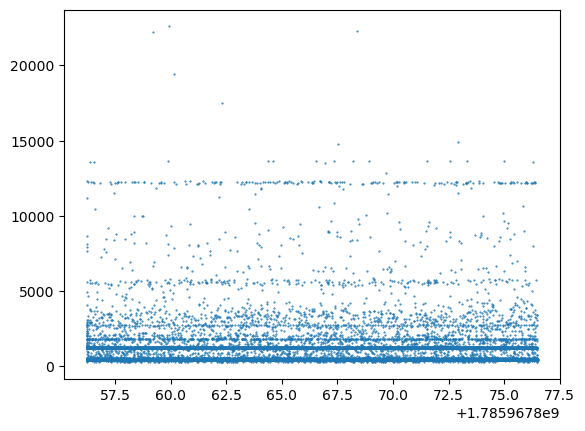

In [44]:
plt.plot(t_unix, energy, '.', markersize=1)

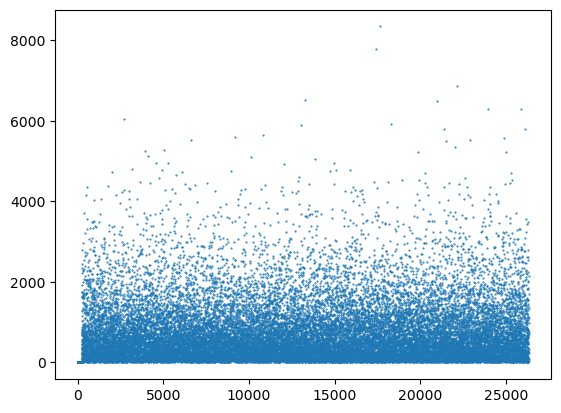

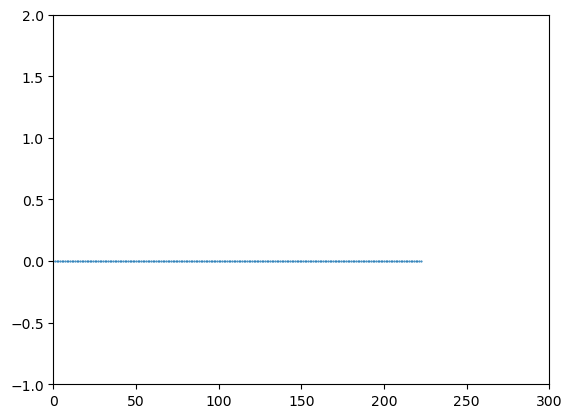

In [48]:
plt.plot(ts_us[1:]-ts_us[:-1], '.', markersize=1)
plt.show()
plt.plot(ts_us[1:]-ts_us[:-1], '.', markersize=1)
plt.ylim(-1, 2)
plt.xlim(0, 300)
plt.show()


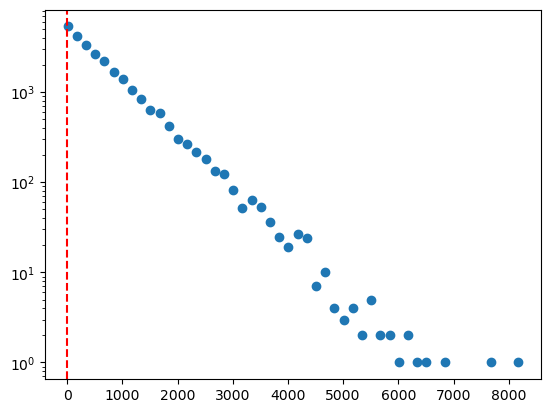

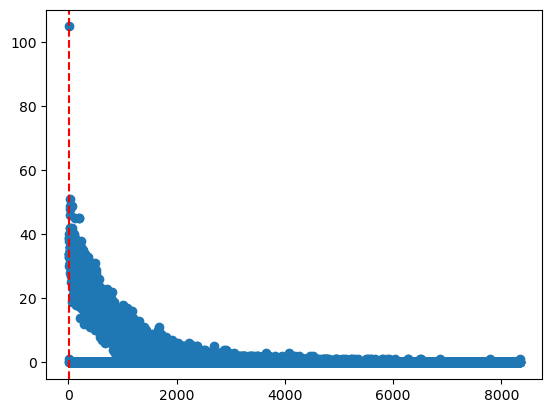

In [60]:
# h,b = np.histogram(ts_us[1:]-ts_us[:-1], np.linspace(0, 1e3, 10000000))
times_us = np.asarray(ts_us[223:], dtype=np.int64)
dt_us = np.diff(times_us)

h,b = np.histogram(dt_us, bins = 50)

plt.scatter(b[:-1], h)
plt.axvline(4.8, color='r', linestyle='--')

plt.yscale('log')
# plt.xlim(4, 1e3)
# plt.xlim(0,1)
# plt.ylim( 400,410)

plt.show()

dt_us = np.diff(np.asarray(ts_us, dtype=np.int64))
dt_us_above_5 = dt_us[dt_us > 5]

h,b = np.histogram(dt_us_above_5, bins = 10000)

plt.scatter(b[:-1], h)
plt.axvline(5, color='r', linestyle='--')
plt.show()

/var/folders/x5/f57jfqdd0rq40qq6hqqmc8gr0000gn/T/ipykernel_2094/4200119200.py:58: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(-1)


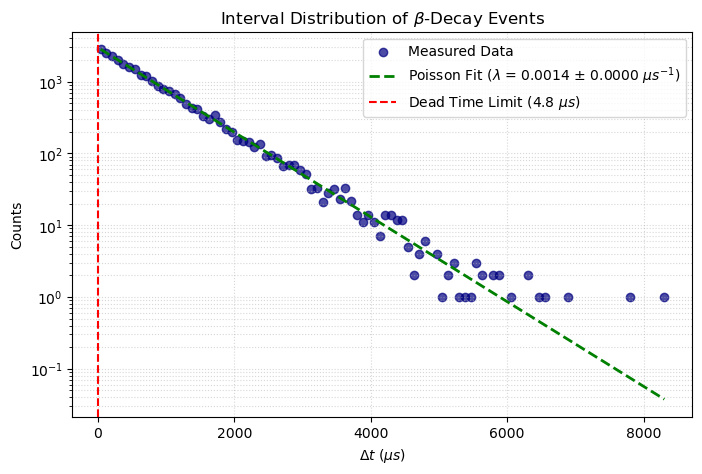

Chi-Square (chi2): 95.65
Degrees of Freedom (dof): 74
Reduced Chi-Square (chi2_red): 1.29


In [114]:


# 1. Compute time differences
times_us = np.asarray(ts_us, dtype=np.int64)
dt_us = np.diff(times_us)

# 2. Histogram with bin centers
bins = 100
counts, bin_edges = np.histogram(dt_us, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# 3. Isolate valid region above dead time cutoff
dead_time_us = 4.8
mask = bin_centers > dead_time_us

fit_x = bin_centers[mask]
fit_y = counts[mask]
# mask = fit_y > 1
# fit_x = bin_centers[mask]
# fit_y = counts[mask]



# Define exponential model shifted by dead time: N(dt) = N0 * exp(-lambda * (dt - t_dead))
def exp_func(dt, N0, lmbda):
    return N0 * np.exp(-lmbda * (dt - dead_time_us))


# Fit only non-zero counts in valid region
nonzero = fit_y > 0
popt, pcov = curve_fit(
    exp_func, fit_x[nonzero], fit_y[nonzero], p0=[fit_y[0], 0.001]
)
fit_N0, fit_lambda = popt
fit_lambda_err = np.sqrt(pcov[1, 1])

# 4. Plot results
plt.figure(figsize=(8, 5))
plt.scatter(
    bin_centers, counts, color="navy", alpha=0.7, label="Measured Data"
)
plt.plot(
    fit_x,
    exp_func(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f} $\pm$ {fit_lambda_err:.4f} $\mu s^{{-1}}$)",
)
plt.axvline(
    dead_time_us,
    color="r",
    linestyle="--",
    label=f"Dead Time Limit ({dead_time_us} $\mu s$)",
)

plt.yscale("log")
plt.xlabel(r"$\Delta t$ ($\mu s$)")
plt.ylabel("Counts")
plt.title(r"Interval Distribution of $\beta$-Decay Events")
plt.ylim(-1)
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()
# 1. Define N_obs and N_fit (excluding bins with zero counts to avoid division by zero)
valid_mask = fit_y > 0  # Bins above dead time with counts > 0

N_obs = fit_y[valid_mask]
N_fit = exp_func(fit_x[valid_mask], *popt)

# 2. Calculate Chi-Square
# Standard error squared for counting statistics is sigma^2 = N_obs
chi2 = np.sum((N_obs - N_fit) ** 2 / N_obs)

# 3. Calculate Degrees of Freedom and Reduced Chi-Square
num_bins = len(N_obs)
num_params = 2  # N0 and lambda
dof = num_bins - num_params

chi2_red = chi2 / dof

print(f"Chi-Square (chi2): {chi2:.2f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Square (chi2_red): {chi2_red:.2f}")


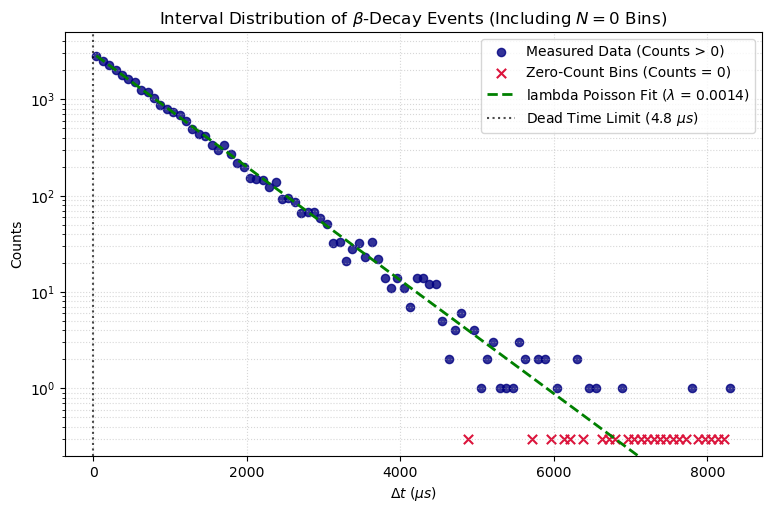

Total bins above dead time: 100
Zero-count bins included in chi2: 24
Chi-Square (chi2): 137.87
Degrees of Freedom (dof): 99
Reduced Chi-Square (chi2_red): 1.39


In [140]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Compute time differences
times_us = np.asarray(ts_us, dtype=np.int64)
dt_us = np.diff(times_us)

# 2. Histogram with bin centers
bins = 100
counts, bin_edges = np.histogram(dt_us, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]  # Calculate exact bin width (delta_b)

# 3. Isolate valid region above dead time cutoff
dead_time_us = 4.8
mask = bin_centers > dead_time_us

fit_x = bin_centers[mask]
fit_y = counts[mask]
N_valid = np.sum(fit_y)  # Total counts in the valid region above dead time


# Normalized 1-parameter exponential model: N(dt) = N_valid * delta_b * lambda * exp(-lambda * (dt - t_dead))
def exp_func(dt, lmbda):
    return N_valid * bin_width * lmbda * np.exp(-lmbda * (dt - dead_time_us))


# Fit the single parameter lambda
popt, pcov = curve_fit(
    exp_func,
    fit_x,
    fit_y,
    p0=[0.001],
)
fit_lambda = popt[0]
fit_lambda_err = np.sqrt(pcov[0, 0])  # 1x1 covariance matrix

# 4. Plotting
plt.figure(figsize=(9, 5.5))

# Separate non-zero and zero bins across the entire histogram
nonzero_mask = counts > 0
zero_mask = counts == 0

# Plot non-zero count bins
plt.scatter(
    bin_centers[nonzero_mask],
    counts[nonzero_mask],
    color="navy",
    alpha=0.8,
    s=35,
    label="Measured Data (Counts > 0)",
)

# Plot zero-count bins explicitly on the log baseline (y = 0.3)
baseline_zero_y = 0.3
plt.scatter(
    bin_centers[zero_mask],
    np.full(np.sum(zero_mask), baseline_zero_y),
    color="crimson",
    marker="x",
    s=45,
    linewidth=1.5,
    label="Zero-Count Bins (Counts = 0)",
)

# Plot exponential fit curve
plt.plot(
    fit_x,
    exp_func(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"lambda Poisson Fit ($\lambda$ = {fit_lambda:.4f})",
)

# Dead time threshold vertical line
plt.axvline(
    dead_time_us,
    color="black",
    linestyle=":",
    alpha=0.7,
    label=f"Dead Time Limit ({dead_time_us} $\mu s$)",
)

plt.yscale("log")
plt.ylim(bottom=0.2)  # Ensures the y = 0.3 baseline markers are visible
plt.xlabel(r"$\Delta t$ ($\mu s$)")
plt.ylabel("Counts")
plt.title(r"Interval Distribution of $\beta$-Decay Events (Including $N=0$ Bins)")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()

# 5. Chi-Square calculation including ALL bins above dead time
N_obs = fit_y  # Includes zero-count bins
N_fit = exp_func(fit_x, *popt)

# Pearson's Chi-Square: uses expected value in denominator
chi2 = np.sum((N_obs - N_fit) ** 2 / N_fit)
num_params = 1  # Fitting only lambda
dof = len(N_obs) - num_params
chi2_red = chi2 / dof

print(f"Total bins above dead time: {len(N_obs)}")
print(f"Zero-count bins included in chi2: {np.sum(N_obs == 0)}")
print(f"Chi-Square (chi2): {chi2:.2f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Square (chi2_red): {chi2_red:.2f}")


In [139]:
# 1. Compute time differences
times_us = np.asarray(ts_us, dtype=np.int64)
dt_us = np.diff(times_us)

# 2. Histogram with bin centers
bins = 100
counts, bin_edges = np.histogram(dt_us, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_width = bin_edges[1] - bin_edges[0]  # Calculate exact bin width (delta_b)

# 3. Isolate valid region above dead time cutoff
dead_time_us = 4.8
mask = bin_centers > dead_time_us

fit_x = bin_centers[mask]
fit_y = counts[mask]


# Exponential model shifted by dead time
def exp_func(dt, N0, lmbda):
    return N0 * np.exp(-lmbda * (dt - dead_time_us))


# Fit using non-zero points only (curve_fit requires y > 0 for exponential fitting)
popt, pcov = curve_fit(
    exp_func,
    fit_x,
    fit_y,
    p0=[fit_y[0], 0.001],
)
fit_N0, fit_lambda = popt

print(fit_lambda)
print(fit_N0/(bin_width*counts.sum()))

0.001359509377273189
0.0013546067530464238


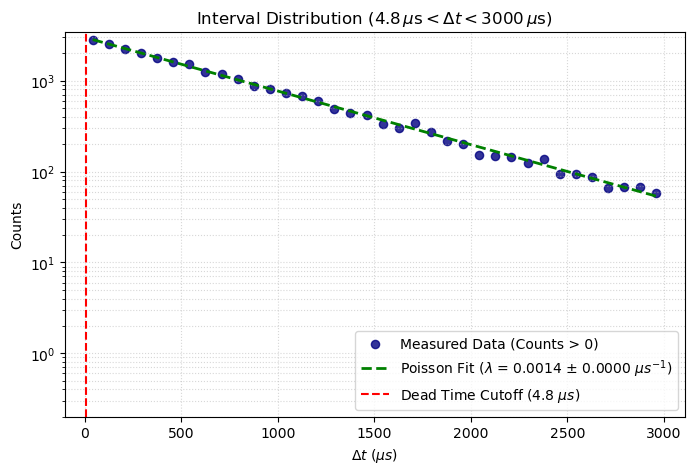

Total bins in range (4.8 to 3000 us): 36
Zero-count bins included in chi2: 0
Chi-Square (chi2): 44.40
Degrees of Freedom (dof): 34
Reduced Chi-Square (chi2_red): 1.31


In [113]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Compute time differences
times_us = np.asarray(ts_us, dtype=np.int64)
dt_us = np.diff(times_us)

# 2. Histogram with bin centers
bins = 100
counts, bin_edges = np.histogram(dt_us, bins=bins)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

# 3. Filter data to ONLY the used region (4.8 us < dt < 3000 us)
dead_time_us = 4.8
max_dt_us = 3000.0

# Single combined boolean mask prevents length-mismatch errors
valid_mask = (bin_centers > dead_time_us) & (bin_centers < max_dt_us)

fit_x = bin_centers[valid_mask]
fit_y = counts[valid_mask]



# Exponential model shifted by dead time
def exp_func(dt, N0, lmbda):
    return N0 * np.exp(-lmbda * (dt - dead_time_us))


# Fit using non-zero bins to prevent log(0) issues during curve optimization
nonzero = fit_y > 0
popt, pcov = curve_fit(
    exp_func, fit_x[nonzero], fit_y[nonzero], p0=[fit_y[nonzero][0], 0.001]
)
fit_N0, fit_lambda = popt
fit_lambda_err = np.sqrt(pcov[1, 1])

# 4. Plot ONLY used region
plt.figure(figsize=(8, 5))

# Plot non-zero bins in filtered window
plt.scatter(
    fit_x[nonzero],
    fit_y[nonzero],
    color="navy",
    alpha=0.8,
    s=35,
    label="Measured Data (Counts > 0)",
)

# Plot zero-count bins explicitly on baseline so log scale doesn't hide them
zero_mask = fit_y == 0
if np.any(zero_mask):
    plt.scatter(
        fit_x[zero_mask],
        np.full(np.sum(zero_mask), 0.3),
        color="crimson",
        marker="x",
        s=40,
        linewidth=1.5,
        label="Zero-Count Bins (Counts = 0)",
    )

# Plot fitted exponential line
plt.plot(
    fit_x,
    exp_func(fit_x, *popt),
    "g--",
    linewidth=2,
    label=f"Poisson Fit ($\lambda$ = {fit_lambda:.4f} $\pm$ {fit_lambda_err:.4f} $\mu s^{{-1}}$)",
)

plt.axvline(
    dead_time_us,
    color="r",
    linestyle="--",
    label=f"Dead Time Cutoff ({dead_time_us} $\mu s$)",
)

plt.yscale("log")
plt.ylim(bottom=0.2)  # Ensures zero-bin markers at 0.3 are visible
plt.xlabel(r"$\Delta t$ ($\mu s$)")
plt.ylabel("Counts")
plt.title(
    r"Interval Distribution ($4.8\,\mu\text{s} < \Delta t < 3000\,\mu\text{s}$)"
)
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()

# 5. Chi-Square calculation including ALL bins in valid window (including zeros)
N_obs = fit_y  # Contains all 0s and non-0s between 4.8 us and 3000 us
N_fit = exp_func(fit_x, *popt)

# Pearson's Chi-Square: N_fit in denominator prevents division by zero for N_obs = 0
chi2 = np.sum((N_obs - N_fit) ** 2 / N_fit)

num_bins = len(N_obs)
num_params = 2  # N0 and lambda
dof = num_bins - num_params

chi2_red = chi2 / dof

print(f"Total bins in range (4.8 to 3000 us): {num_bins}")
print(f"Zero-count bins included in chi2: {np.sum(zero_mask)}")
print(f"Chi-Square (chi2): {chi2:.2f}")
print(f"Degrees of Freedom (dof): {dof}")
print(f"Reduced Chi-Square (chi2_red): {chi2_red:.2f}")


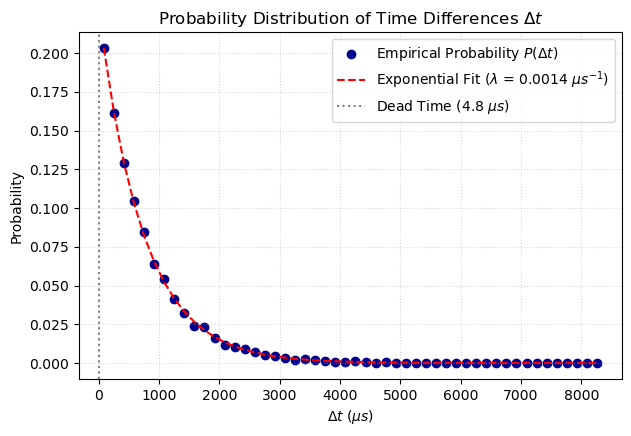

In [75]:

# 1. Compute time differences
times_us = np.asarray(ts_us, dtype=np.int64)
dt_us = np.diff(times_us)

# 2. Histogram counts & convert to empirical probabilities
counts, bin_edges = np.histogram(dt_us, bins=50)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
prob_dt = counts / np.sum(counts)  # Empirical probability per bin

# 3. Fit exponential probability above dead time threshold (4.8 us)
dead_time = 4.8
mask = bin_centers > dead_time

fit_x = bin_centers[mask]
fit_y = prob_dt[mask]


def exp_prob(dt, P0, lmbda):
    return P0 * np.exp(-lmbda * (dt - dead_time))


nonzero = fit_y > 0
popt, _ = curve_fit(
    exp_prob, fit_x[nonzero], fit_y[nonzero], p0=[fit_y[0], 0.001]
)

# Plot normalized probability
plt.figure(figsize=(7, 4.5))
plt.scatter(
    bin_centers,
    prob_dt,
    color="darkblue",
    label="Empirical Probability $P(\Delta t)$",
)
plt.plot(
    fit_x,
    exp_prob(fit_x, *popt),
    "r--",
    label=f"Exponential Fit ($\lambda$ = {popt[1]:.4f} $\mu s^{{-1}}$)",
)
plt.axvline(
    dead_time, color="gray", linestyle=":", label=f"Dead Time ({dead_time} $\mu s$)"
)
# plt.yscale("log")
plt.xlabel(r"$\Delta t$ ($\mu s$)")
plt.ylabel("Probability")
plt.title(r"Probability Distribution of Time Differences $\Delta t$")
plt.legend()
plt.grid(True, which="both", linestyle=":", alpha=0.5)
plt.show()


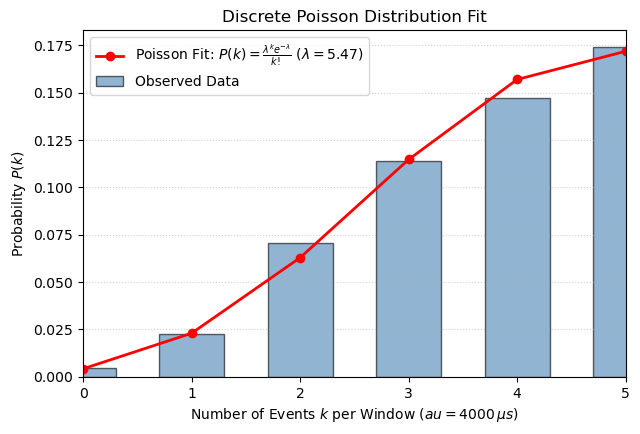

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np
# from scipy.optimize import curve_fit
# from scipy.special import factorial


# # 1. Define fixed time window length tau (in microseconds)
# tau = 4000  # Choose window size so average events per window is ~1 to 5

# # 2. Bin timestamps into fixed windows to get counts k per window
# window_edges = np.arange(times_us[0], times_us[-1], tau)
# k_counts, _ = np.histogram(times_us, bins=window_edges)

# # 3. Calculate observed probabilities for each count value k (0, 1, 2, ...)
# max_k = np.max(k_counts)
# k_values = np.arange(0, max_k + 1)
# k_freq, _ = np.histogram(k_counts, bins=np.arange(-0.5, max_k + 1.5, 1))
# p_k_obs = k_freq / np.sum(k_freq)  # Probability of observing k events in time tau


# # 4. Define the Poisson PMF equation from image: P(k) = (lambda^k * exp(-lambda)) / k!
# def poisson_pmf(k, lmbda):
#     return (lmbda**k * np.exp(-lmbda)) / factorial(k)


# # 5. Fit the Poisson model to observed probabilities
# popt, pcov = curve_fit(poisson_pmf, k_values, p_k_obs, p0=[np.mean(k_counts)])
# fit_lambda = popt[0]

# # 6. Plot observed vs fitted Poisson distribution
# plt.figure(figsize=(7, 4.5))
# plt.bar(
#     k_values,
#     p_k_obs,
#     width=0.6,
#     alpha=0.6,
#     color="steelblue",
#     edgecolor="black",
#     label="Observed Data",
# )
# plt.plot(
#     k_values,
#     poisson_pmf(k_values, fit_lambda),
#     "ro-",
#     linewidth=2,
#     label=f"Poisson Fit: $P(k) = \\frac{{\lambda^k e^{{-\lambda}}}}{{k!}}$ ($\lambda = {fit_lambda:.2f}$)",
# )

# plt.xlabel(f"Number of Events $k$ per Window ($\tau = {tau}\,\mu s$)")
# plt.ylabel("Probability $P(k)$")
# plt.title("Discrete Poisson Distribution Fit")
# # plt.xticks(k_values)
# plt.legend()
# plt.grid(True, axis="y", linestyle=":", alpha=0.6)
# plt.xlim(0,5)
# plt.show()


Mean (μ): 52.21 counts/interval
Variance (σ²): 51.48
Fano Factor (F = σ²/μ): 0.986
--> Counts closely follow Poissonian statistics (F ~ 1).
Chi-Square Statistic: 100.98, p-value: 0.0000


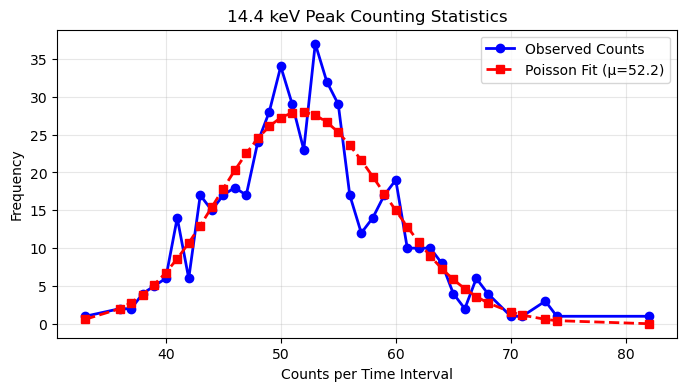

In [63]:

from scipy.stats import chisquare, poisson


num_intervals = 500  # Split full dataset time range into 50 equal time windows
counts_per_interval, _ = np.histogram(
    t_unix[223:], bins=num_intervals, range=(t_unix[223], t_unix[-1])
)


mean_counts = np.mean(counts_per_interval)
var_counts = np.var(counts_per_interval, ddof=1)
fano_factor = var_counts / mean_counts if mean_counts > 0 else 0

print(f"Mean (μ): {mean_counts:.2f} counts/interval")
print(f"Variance (σ²): {var_counts:.2f}")
print(f"Fano Factor (F = σ²/μ): {fano_factor:.3f}")

if 0.8 <= fano_factor <= 1.2:
    print("--> Counts closely follow Poissonian statistics (F ~ 1).")
elif fano_factor > 1.2:
    print(
        "--> Overdispersed (F > 1): Possible detector drift, pile-up, or background noise."
    )
else:
    print("--> Underdispersed (F < 1): Possible dead-time losses or filtering.")

# -------------------------------------------------------------
# Step 5: Theoretical Poisson Fit & Chi-Square Test
# -------------------------------------------------------------
unique_counts, observed_freq = np.unique(
    counts_per_interval, return_counts=True
)

expected_prob = poisson.pmf(unique_counts, mu=mean_counts)
expected_freq = expected_prob * len(counts_per_interval)
expected_freq *= np.sum(observed_freq) / np.sum(expected_freq)

chi2_stat, p_val = chisquare(f_obs=observed_freq, f_exp=expected_freq)
print(f"Chi-Square Statistic: {chi2_stat:.2f}, p-value: {p_val:.4f}")

# -------------------------------------------------------------
# Step 6: Plotting using plt.plot
# -------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(
    unique_counts,
    observed_freq,
    "b-o",
    linewidth=2,
    markersize=6,
    label="Observed Counts",
)
plt.plot(
    unique_counts,
    expected_freq,
    "r--s",
    linewidth=2,
    markersize=6,
    label=f"Poisson Fit (μ={mean_counts:.1f})",
)

plt.xlabel("Counts per Time Interval")
plt.ylabel("Frequency")
plt.title("14.4 keV Peak Counting Statistics")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


/Users/ezriadelsbach/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


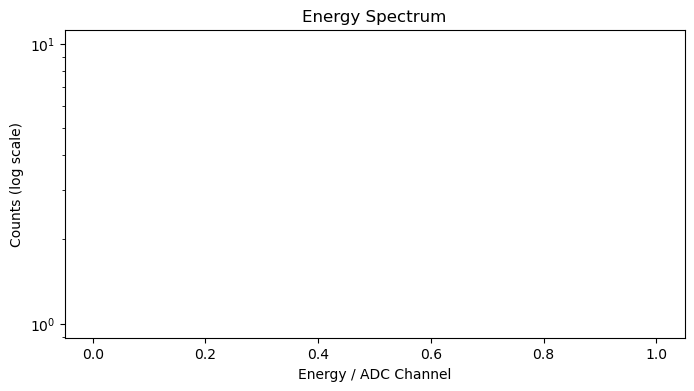

In [29]:


# # 1. Correct Plot for Raw Event Sequence
# plt.figure(figsize=(8, 4))
# plt.plot(energy, linewidth=0.5)
# plt.title("Pulse Height per Event")
# plt.xlabel("Event Index")
# plt.ylabel("Energy / ADC Channel")
# plt.show()

# 2. Correct Plot for True Energy Spectrum
plt.figure(figsize=(8, 4))
plt.hist(energy, bins=1024, log=True)
plt.title("Energy Spectrum")
plt.xlabel("Energy / ADC Channel")
plt.ylabel("Counts (log scale)")
plt.show()

In [52]:

times = np.asarray(ts_us, dtype=np.float64)   # seconds
adu = np.asarray(energy, dtype=np.int32)

dt = np.diff(times)
dadu = np.diff(adu)
abs_dadu = np.abs(dadu)

# Select time-spacing groups
zero_mask = np.isclose(dt, 0.0, atol=1e-9)

target_dt = 1       # seconds
tolerance = 0.001    
target_mask = np.abs(dt - target_dt) <= tolerance


def summarize(label, mask):
    values = abs_dadu[mask]

    if values.size == 0:
        print(f"{label}: no matching pairs")
        return

    mean_abs = np.mean(values)
    max_abs = np.max(values)

    print(f"{label}")
    print(f"  Number of pairs:       {values.size}")
    print(f"  Mean absolute ΔADU:    {mean_abs:.3f}")
    print(f"  Max absolute ΔADU:  {max_abs:.3f}")

summarize("Δt = 0", zero_mask)
summarize("Δt ≈ 1 seconds", target_mask)

Δt = 0
  Number of pairs:       223
  Mean absolute ΔADU:    881.955
  Max absolute ΔADU:  11869.000
Δt ≈ 1 seconds: no matching pairs


In [31]:
# def adu_to_kev(adu, gain, offset):
#     global C1, C2, C3, C4
#     return (1 / (C1 * gain)) * (adu - C2 * gain - C3 * offset) + C4

# def kev_to_adu(kev, gain, offset):
#     global C1, C2, C3, C4

#     return ((kev - C4) * (C1 * gain) + C2 * gain + C3 * offset)

In [32]:


# def adu_to_kev(adu, gain, offset):
#     return (1 / (C1 * gain)) * (adu - C2 * gain - C3 * offset) + C4

# def kev_to_adu( kev, gain, offset):
#     return (kev - C4) * (C1 * gain) + C2 * gain + C3 * offset

In [33]:
# MAX_Q15 = 32767 / 32768

# dev.set_register("peak_detector", "trig_level", 0.08)
# dev.set_register("peak_detector", "n_integration", 300)

# log = EventLogger(dev)
# log.configure(
#     band_low=0.0,
#     band_high=MAX_Q15,
#     flush_ms=100,
# )

# print("trigger:", dev.get_register("peak_detector", "trig_level", raw=True))
# print("integration:", dev.get_register("peak_detector", "n_integration", raw=True))
# print("logger band:", [
#     dev.get_register("event_logger", "band_low", raw=True),
#     dev.get_register("event_logger", "band_high", raw=True),
# ])

In [34]:
# log.arm(clear=True)

# for _ in range(10):
#     print(
#         "events =", dev.get_register("event_logger", "events_lo", raw=True),
#         "ready =", dev.get_register("event_logger", "ready", raw=True),
#         "count =", dev.get_register("event_logger", "ready_count", raw=True),
#         "peak =", dev.get_register("peak_detector", "peak_max_out", raw=True),
#     )
#     time.sleep(0.2)

# log.disarm()

In [35]:
# n = log.run(duration=5, output_dir="run2")
# print("drained events:", n)
# print("dropped:", log.dropped())

In [36]:
# log.arm(clear=True)

# # Signal chain
# dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)

# for idx in range(9):
#     dev.set_register("fir9", f"h{idx}", 0.109375)


# # Peak detector
# dev.set_register("peak_detector", "trig_level", 0.008, raw=True)
# # dev.set_register("peak_detector", "fall_level", 1, raw=True)
# # dev.set_register("peak_detector", "base_return", 0, raw=True)
# # dev.set_register("peak_detector", "dead_time", 1000, raw=True)

# # Use 0 for positive-going pulses, 1 for negative-going pulses
# dev.set_register("peak_detector", "invert_input", 0, raw=True)


# dev.set_register("peak_detector", "n_integration", 300)

# # Histogram
# dev.set_register("histogram", "offset", -0.007165694774164504)
# dev.set_register("histogram", "gain", 0.08361136196556104)

# dev.set_register("histogram", "pulse_width", 1024)
# dev.set_register("histogram", "clear_bins", 1)
# time.sleep(0.01)
# dev.set_register("histogram", "clear_bins", 0)
# dev.set_register("histogram", "counting_enable", 1)
# # dev.set_register("histogram", "band_low", 0.0)
# # dev.set_register("histogram", "band_high", MAX_Q15)

# log = EventLogger(dev)
# log.configure(flush_ms=100)
# # log. /configure(flush_ms=100)

# log.run(duration=5, output_dir=f"{runfile}")

# log.disarm()

In [37]:

# RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
# dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
# dev.base.load_bitfile()

# # Signal chain
# dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)
# dev.set_register('fir9', 'h0', 0.99)

# # Peak detector
# dev.set_register("peak_detector", "invert_input", 0)
# dev.set_register("peak_detector", "trig_level", 0.01)
# dev.set_register("peak_detector", "integration_mode", 0)
# dev.set_register("peak_detector", "n_integration", 1000)

# # Histogram
# dev.set_register("histogram", "offset", 0)
# dev.set_register("histogram", "gain", 0.1)
# dev.set_register("histogram", "band_low", 0.03)
# dev.set_register("histogram", "band_high", 0.35)
# dev.set_register("histogram", "pulse_width", 1024)
# dev.set_register("histogram", "clear_bins", 1)
# time.sleep(0.01)
# dev.set_register("histogram", "clear_bins", 0)

# log = EventLogger(dev)
# log.configure(flush_ms=100)
# log.run(duration=6, output_dir="run1")

In [38]:
# histogram = dev.read_sequential_axi_data("histogram", "read_address", "read_data", 0, 1023)
# plt.plot(histogram)

In [39]:
# dev.get_all_registers("histogram")
# # offset